In [19]:
from pathlib import Path
import geopandas as gpd
import folium 
from shapely.geometry import LineString, Polygon, box
import rasterio
import matplotlib.pyplot as plt
from shapely.geometry import shape

import numpy as np
import geopandas as gpd
from scipy.spatial import Voronoi
from shapely.geometry import Polygon

from shapely.geometry import Point
from rasterio.transform import Affine
from scipy.optimize import root_scalar

import os

In [20]:
# root_dir = Path(r'C:\python\Use_case_stedin')
root_dir = Path.cwd().parent
assert root_dir.exists()
print(f"Root directory: {root_dir}")
electricity_data_path = root_dir / 'data' / 'electricity'
# electricity_data_path = Path(r'C:\Data\raw\StedinData')
assert electricity_data_path.exists()

Root directory: c:\repos\powerpath


In [3]:
ls_station_path = electricity_data_path.joinpath("ls_stations_clipped.shp")
# ls_station_path = electricity_data_path.joinpath("Laagspanningsstations\Laagspanningsstations.shp")
ls_stations = gpd.read_file(ls_station_path).to_crs("EPSG:28992")  # Ensure CRS matches
ls_stations_centroids = ls_stations['geometry'].representative_point()
bounding_box_ls = ls_stations_centroids.unary_union.convex_hull

msls_station_path = electricity_data_path.joinpath("msls_stations_clipped.shp")
# msls_station_path = electricity_data_path.joinpath("MiddenLaagspanningsstations\MiddenLaagspanningsstations.shp")
msls_stations = gpd.read_file(msls_station_path).to_crs("EPSG:28992")  # Ensure CRS matches
msls_stations_centroids = msls_stations['geometry'].representative_point()
bounding_box_msls = msls_stations_centroids.unary_union.convex_hull

ms_station_path = electricity_data_path.joinpath("ms_stations_clipped.shp")
# ms_station_path = electricity_data_path.joinpath("Middenspanningsstations\Middenspanningsstations.shp")
ms_stations = gpd.read_file(ms_station_path).to_crs("EPSG:28992")  # Ensure CRS matches
ms_stations_centroids = ms_stations['geometry'].representative_point()
bounding_box_ms = ms_stations_centroids.unary_union.convex_hull

hazard_path = root_dir / 'data' / 'static' / 'hazard' / 'processed' / 'timesteps'
# hazard_path = r'N:\Projects\11209000\11209175\B. Measurements and calculations\Data\hazard_maps_time_series_waterbom\Delfland\tijdserie'

In [4]:
# Functions
def voronoi_polygons(gdf, bounding_box):
    points = gdf.geometry.apply(lambda geom: (geom.x, geom.y)).tolist()
    vor = Voronoi(points)
    polygons = []
    for region in vor.regions:
        if not -1 in region and len(region) > 0:
            polygon = Polygon([vor.vertices[i] for i in region])
            clipped_polygon = polygon.intersection(bounding_box)
            polygons.append(clipped_polygon)
    return gpd.GeoDataFrame(geometry=polygons)

# Function to get the raster value at a point
def get_raster_value(raster, point):
    row, col = raster.index(point.x, point.y)
    if 0 <= row < raster.height and 0 <= col < raster.width:
        value = raster.read(1)[row, col]
    else:
        value = None  # or some default value indicating out of bounds
    return value


# def assign_hazard_to_voronoi(points_with_hazard, voronoi_gdf_msls):
#     # Ensure both GeoDataFrames have the same CRS
#     if points_with_hazard.crs != voronoi_gdf_msls.crs:
#         points_with_hazard = points_with_hazard.to_crs(voronoi_gdf_msls.crs)
    
#     # Perform spatial join to find polygons containing points
#     joined_gdf = gpd.sjoin(voronoi_gdf_msls, points_with_hazard, how="inner", predicate="contains")
    
#     # Group by Voronoi polygon and aggregate hazard values
#     voronoi_with_hazard = joined_gdf.groupby(joined_gdf.index).agg({'hazard_value': 'mean'}).reset_index()
    
#     # Merge the aggregated hazard values back to the original Voronoi GeoDataFrame
#     voronoi_gdf_msls = voronoi_gdf_msls.merge(voronoi_with_hazard, left_index=True, right_on='index', how='left')
    
#     return voronoi_gdf_msls


def assign_hazard_to_voronoi(points_with_hazard, voronoi):
    # Ensure both GeoDataFrames have the same CRS
    if points_with_hazard.crs != voronoi.crs:
        points_with_hazard = points_with_hazard.to_crs(voronoi.crs)
    
    # Drop points with NaN geometry or hazard values
    points_with_hazard = points_with_hazard.dropna(subset=['geometry', 'hazard_value'])
    
    # Perform spatial join to find polygons containing points
    joined_gdf = gpd.sjoin(voronoi, points_with_hazard, how="inner", predicate="contains")
    
    # Group by Voronoi polygon and aggregate hazard values
    voronoi_with_hazard = joined_gdf.groupby(joined_gdf.index).agg({'hazard_value': 'mean'}).reset_index()
    
    # Merge the aggregated hazard values back to the original Voronoi GeoDataFrame
    voronoi = voronoi.merge(voronoi_with_hazard, left_index=True, right_on='index', how='left')
    
    return voronoi

def find_hazard_value_at_points(hazard_map, gdf, timestep=None):
    """    Find hazard values at point geometries in a GeoDataFrame using a raster hazard map.
    
    Parameters:
    hazard_map (str or Path): Path to the raster hazard map file.
    gdf (gpd.GeoDataFrame): GeoDataFrame with point geometries.
    timestep (int, optional): Timestep for hazard value extraction. If None, uses the latest hazard map.
    
    Returns:
    gpd.GeoDataFrame: GeoDataFrame with hazard values added as a new column.
    """
    with rasterio.open(hazard_map) as src:
        gdf = gdf.to_crs(src.crs)  # Ensure CRS matches

        if timestep is None:
            gdf['hazard_value'] = gdf.geometry.apply(lambda geom: get_raster_value(src, geom))
        else:
            hazval_str= f'hazard_value_{timestep:02d}'
            gdf[hazval_str] = gdf.geometry.apply(lambda geom: get_raster_value(src, geom))
    return gdf

In [5]:

def default_damage_ratio_function(hazard_values, coefficients):
    # Example: linear function, adjust as needed
    m, n = coefficients
    return m * hazard_values + n

def default_repair_time_function(damage_ratios, coefficients):
    # Example: polynomial function, adjust as needed
    a, b, c = coefficients
    return a * (damage_ratios ** 2) + b * damage_ratios + c

def solve_damage_ratio_from_repair_time(repair_time, coefficients):
    """
    Numerically solve for the damage ratio given a repair time and polynomial coefficients.
    repair_time = a * DR^2 + b * DR + c
    """
    a, b, c = coefficients
    # Define the function whose root we want to find
    def func(dr):
        return a * dr**2 + b * dr + c - repair_time
    # Solve for dr in [0, 1]
    sol = root_scalar(func, bracket=[0, 1], method='brentq')
    if sol.converged:
        return sol.root
    else:
        return 0.0  # or np.nan 

def simulate_asset_damage_recovery(
    gdf_assets, 
    hazard_path, 
    timesteps=None,
    damage_ratio_func=default_damage_ratio_function,
    repair_time_func=default_repair_time_function,
    damage_ratio_coefficients=(0.0468, 0.0077), #(FEMA, 2009; Sánchez-Muñoz et al., 2020) USA
    repair_time_coefficients=(702.72, 3.14, 1.9891), #(Sánchez-Muñoz et al., 2020) Bristol(UK)/Barcelona(SP)
    flood_threshold=0.2, # Ref?
    repair_threshold=2.0, # Repair time threshold for recovery calculation, set to 2 hours (1.9891) as lower limit of the repair time curve
    record_results=True,
    verbose=True
):
    """
    Simulate asset damage and recovery over timesteps using NumPy arrays for optimization.
    
    Parameters:
    gdf_assets (gpd.GeoDataFrame): GeoDataFrame with asset geometries
    hazard_path (Path): Path to hazard map files
    timesteps (np.array): Array of timestep values (default: 0 to 7*24+1)
    damage_ratio_func (callable): Function to calculate damage ratio from hazard values
    repair_time_func (callable): Function to calculate repair time from damage ratios
    damage_ratio_coefficients (tuple): Coefficients for damage ratio function (m, n)
    repair_time_coefficients (tuple): Coefficients for repair time polynomial (a, b, c)
    flood_threshold (float): Hazard value threshold for flooding (default: 0.2)
    repair_threshold (float): Repair time threshold for recovery calculation (default: 2.0)
    record_results (bool): Whether to record timestep results (default: True)
    verbose (bool): Whether to print progress messages (default: True)
    
    Returns:
    tuple: (final_gdf, results_dict) - Final asset states and recorded results
    """
    
    if timesteps is None:
        timesteps = np.arange(0, 7*24+1, 1)

    # Convert to NumPy arrays for optimized operations
    n_assets = len(gdf_assets)

    # Initialize NumPy arrays for asset states
    damage_ratio = np.zeros(n_assets, dtype=np.float64)
    repair_time = np.zeros(n_assets, dtype=np.float64)
    accessible = np.ones(n_assets, dtype=bool)
    operational = np.ones(n_assets, dtype=bool)
    current_hazard_values = np.zeros(n_assets, dtype=np.float64)

    # Create temporary GeoDataFrame for hazard value extraction
    temp_gdf = gdf_assets.copy()

    # Results recording
    recorded_variables = ['asset_id', 'timestep', 'day', 'damage_ratio', 'repair_time', 'accessible', 'operational', 'hazard_value']
    results = {var: [] for var in recorded_variables} if record_results else None

    # Iterate over each timestep
    for timestep in timesteps:
        day_counter = timestep // 24
        day_counter_str = str(day_counter).zfill(2)

        # Every 24 hour-timesteps, process the hazard map for that day
        if timestep % 24 == 0:
            # Load hazard map for this day
            # hazard_map = hazard_path / f'20220610 JF  Limburgbui 200 mm 48h  voormalen 15 cm  GHG_waterschijf_1900-01-{(day_counter+3):02d}_scale_5.tif'#f'clipped_hazard_map_{day_counter:02d}.tif'
            hazard_map = hazard_path / f'clipped_hazard_map_{day_counter_str}.tif'
            if not hazard_map.exists():
                if verbose:
                    print(f"Warning: Hazard map for day {day_counter} does not exist at {hazard_map}")
                current_hazard_values.fill(0.0)
            else:
                if verbose:
                    print(f"Processing timestep {timestep} (day {day_counter})")
                # Extract hazard values using the existing function
                temp_gdf = find_hazard_value_at_points(hazard_map, temp_gdf, day_counter)
                haz_val_str = f'hazard_value_{day_counter_str}'
                current_hazard_values = temp_gdf[haz_val_str].fillna(0.0).values

            # Vectorized operations using NumPy arrays
            flooded_mask = current_hazard_values > flood_threshold
            operational[flooded_mask] = False

            # For assets under repair, solve for current damage ratio
            repair_mask = repair_time > repair_threshold
            if np.any(repair_mask):
                repair_indices = np.where(repair_mask)[0]
                for idx in repair_indices:
                    damage_ratio[idx] = solve_damage_ratio_from_repair_time(
                        repair_time[idx], repair_time_coefficients
                    )

            # Update damage ratio for flooded assets (cumulative damage)
            if np.any(flooded_mask):
                dr_new = damage_ratio_func(current_hazard_values[flooded_mask], damage_ratio_coefficients)
                damage_ratio[flooded_mask] = np.maximum(damage_ratio[flooded_mask], dr_new)

            # Only recalculate repair time for assets with damage > 0
            damaged_mask = damage_ratio > 0
            if np.any(damaged_mask):
                repair_time[damaged_mask] = repair_time_func(
                    damage_ratio[damaged_mask], repair_time_coefficients
                )

        # For each timestep, decrement repair_time if accessible and not flooded [TODO]: add if available repair crews/resources 
        can_repair_mask = accessible & (current_hazard_values <= 0.0)
        repair_time[can_repair_mask] = np.maximum(repair_time[can_repair_mask] - 1, 0)
        
        # Check for completed repairs
        newly_operational = (repair_time == 0) & (~operational)
        if np.any(newly_operational):
            operational[newly_operational] = True
            damage_ratio[newly_operational] = 0.0
            if verbose:
                newly_operational_indices = np.where(newly_operational)[0]
                for idx in newly_operational_indices:
                    print(f"Asset {idx} is operational at timestep {timestep}")

        # Record results for each asset at this timestep
        if record_results:
            n_records = len(damage_ratio)
            results['asset_id'].extend(range(n_records))
            results['timestep'].extend([timestep] * n_records)
            results['day'].extend([day_counter] * n_records)
            results['damage_ratio'].extend(damage_ratio.tolist())
            results['repair_time'].extend(repair_time.tolist())
            results['accessible'].extend(accessible.tolist())
            results['operational'].extend(operational.tolist())
            results['hazard_value'].extend(current_hazard_values.tolist())

    if verbose:
        print("Processing complete")

    # Convert final results back to GeoDataFrame for compatibility
    final_gdf = gdf_assets.copy()
    final_gdf['damage_ratio'] = damage_ratio
    final_gdf['repair_time'] = repair_time
    final_gdf['accessible'] = accessible
    final_gdf['operational'] = operational
    final_gdf['final_hazard_value'] = current_hazard_values

    return final_gdf, results



In [6]:


# Assuming 'gdf' is your GeoDataFrame with point geometries
gdf_ls = ls_stations_centroids.set_crs("EPSG:28992")
gdf_ms = ms_stations_centroids.set_crs("EPSG:28992")
gdf_msls = msls_stations_centroids.set_crs("EPSG:28992")
# gdf_hs = hs_stations_centroids.set_crs("EPSG:28992")


voronoi_gdf_ls = voronoi_polygons(gdf_ls, bounding_box_ls)
voronoi_gdf_ms = voronoi_polygons(gdf_ms, bounding_box_ms)
voronoi_gdf_msls = voronoi_polygons(gdf_msls, bounding_box_msls)
# voronoi_gdf_hs = voronoi_polygons(gdf_hs, bounding_box_hs)

voronoi_gdf_ls = voronoi_gdf_ls.set_crs("EPSG:28992")
voronoi_gdf_ms = voronoi_gdf_ms.set_crs("EPSG:28992")
voronoi_gdf_msls = voronoi_gdf_msls.set_crs("EPSG:28992")
# voronoi_gdf_hs = voronoi_gdf_hs.set_crs("EPSG:28992")

#voronoi_gdf = voronoi_gdf[voronoi_gdf.is_valid]


In [7]:
# Plotting
m = voronoi_gdf_msls.explore(color='orange', tooltip=False)
gdf_msls.explore(m=m, marker_kwds={'color': 'blue', 'radius': 1})

In [8]:
# hazard_map = hazard_path.joinpath("delfland_ghg200m_wgs84_processed.tif")
# # Open the TIF file using rasterio
# with rasterio.open(hazard_map) as src:
#     # Read the TIF file as a numpy array
#     tif_array = src.read(1)  # Change the band index (1) if necessary

# plt.figure(figsize=(10, 10))
# plt.imshow(tif_array, cmap='Blues_r')  # Change the colormap if desired
# plt.colorbar(label='Pixel Values')
# plt.title('hazard map')
# plt.show()  

In [9]:
# Assuming gdf_msls is already a GeoDataFrame or a DataFrame with geometry data
gdf_msls_2 = gpd.GeoDataFrame()
gdf_msls_2['geometry'] = gdf_msls.geometry
# gdf_msls_2

C:\Users\peregrin\AppData\Local\Temp\ipykernel_20680\3902121576.py:3: FutureWarning: You are adding a column named 'geometry' to a GeoDataFrame constructed without an active geometry column. Currently, this automatically sets the active geometry column to 'geometry' but in the future that will no longer happen. Instead, either provide geometry to the GeoDataFrame constructor (GeoDataFrame(... geometry=GeoSeries()) or use `set_geometry('geometry')` to explicitly set the active geometry column.
  gdf_msls_2['geometry'] = gdf_msls.geometry


In [10]:
# Initialize an empty list to store GeoTIFF file names
geotiff_files = []


# Find all GeoTIFF files in the folder
for filename in os.listdir(hazard_path):
    if filename.lower().endswith((".tif", ".tiff")):
        geotiff_files.append(os.path.join(hazard_path, filename))

# Initialize variables for overall extent
min_lon, min_lat = float("inf"), float("inf")
max_lon, max_lat = float("-inf"), float("-inf")

# Loop over the GeoTIFF files
for geotiff_file in geotiff_files:
    with rasterio.open(geotiff_file) as src:
        #print(src.crs)
        bounds = src.bounds
       # print(geotiff_files,src.crs)
        
        min_lon = min(min_lon, bounds.left)
        min_lat = min(min_lat, bounds.bottom)
        max_lon = max(max_lon, bounds.right)
        max_lat = max(max_lat, bounds.top)

# Overall geospatial extent
#print(f"Min Longitude: {min_lon}, Max Longitude: {max_lon}")
#print(f"Min Latitude: {min_lat}, Max Latitude: {max_lat}")

# Create a Shapely polygon
polygon = box(min_lon, min_lat, max_lon, max_lat)

gdf_polygon = gpd.GeoDataFrame(index=[0], crs='epsg:4326', geometry=[polygon])

# Calculate width and height
height = max_lon - min_lon
width = max_lat - min_lat

buffer_polygon_network = polygon.buffer(height)

gdf_buffer_polygon_network = gpd.GeoDataFrame(index=[0], crs='epsg:28992', geometry=[buffer_polygon_network])
# gdf_buffer_polygon_network.explore(color='green')

Clippen op de waterkaart

In [11]:
# raster = hazard_map

In [12]:
# # Read the raster file
# with rasterio.open(hazard_map) as src:
#     # Read the TIF file as a numpy array
#     tif_array = src.read(1)  # Change the band index (1) if necessary

#     # Get the CRS from the rasterio object
#     raster_crs = src.crs

#     points = gdf_msls_2

#     # Ensure CRS match
#     points = points.to_crs(raster_crs)
#     points2 = gpd.clip(points, buffer_polygon_network)

#     # Filter points that fall within the raster bounds
#     points2 = points2[points2.geometry.apply(lambda point: 0 <= src.index(point.x, point.y)[0] < src.height and 0 <= src.index(point.x, point.y)[1] < src.width)]

#     # Add a new column to store hazard values
#     points2['hazard_value'] = points2.geometry.apply(lambda point: get_raster_value(src, point))



In [13]:
# gdf_test = find_hazard_value_at_points(hazard_map, gdf_msls_2)
# gdf_test = gdf_test[gdf_test['hazard_value'] > 0.2]
# gdf_test.explore(column='hazard_value', cmap='viridis_r', tiles='CartoDB positron',marker_kwds={'radius': 6})

In [14]:
# result = assign_hazard_to_voronoi(points_with_hazard, voronoi_gdf_msls)
# result = assign_hazard_to_voronoi(gdf_test, voronoi_gdf_msls)

In [15]:

# result_with_hazard = result[result['hazard_value']>0.2]
# result_with_hazard.explore(column='hazard_value',cmap='viridis_r', tiles='CartoDB positron')

# Recovery

In [16]:
# recovery function repair_time(hours) = 702.72*DR^2 + 3.14.95*DR + 1.9891
rec_dr_1 = 702.72 * 1**2 + 3.14 * 1 + 1.9891
rec_dr_05 = 702.72 * 0.5**2 + 3.14 * 0.5 + 1.9891
rec_dr_01 = 702.72 * 0.1**2 + 3.14 * 0.1 + 1.9891
rec_dr_001 = 702.72 * 0.01**2 + 3.14 * 0.01 + 1.9891
rec_dr_0 = 702.72 * 0**2 + 3.14 * 0 + 1.9891

print(f"Recovery time for DR=1: {rec_dr_1} hours")
print(f"Recovery time for DR=0.5: {rec_dr_05} hours")
print(f"Recovery time for DR=0.1: {rec_dr_01} hours")
print(f"Recovery time for DR=0.01: {rec_dr_001} hours")
print(f"Recovery time for DR=0: {rec_dr_0} hours")

# when evaluating repair status, the repair time is bound by the lower limit of the repair time curve, in this case ~2 hr (1.9891)


Recovery time for DR=1: 707.8491 hours
Recovery time for DR=0.5: 179.2391 hours
Recovery time for DR=0.1: 9.330300000000001 hours
Recovery time for DR=0.01: 2.0907720000000003 hours
Recovery time for DR=0: 1.9891 hours


In [17]:
# Run simulation with the default parameters for repair time and damage ratio functions
gdf_msls_timesteps, results = simulate_asset_damage_recovery(
    gdf_msls_2, # GeoDataFrame with station geometries
    Path(hazard_path), # Path to hazard maps
    timesteps=np.arange(0, 7*24+1, 1), # 24-hour timesteps for 7 days
    verbose=True, # Print progress messages
    record_results=True, # Record results for each timestep
    flood_threshold=0.2, # [m] threshold for flooding
    repair_threshold=2.0 # [hours] threshold for repair time to be considered under repair
)

gdf_msls_timesteps.head()

Processing timestep 0 (day 0)
Processing timestep 24 (day 1)
Processing timestep 48 (day 2)
Processing timestep 72 (day 3)
Processing timestep 96 (day 4)
Asset 136 is operational at timestep 99
Asset 158 is operational at timestep 99
Processing timestep 120 (day 5)
Processing timestep 144 (day 6)
Processing timestep 168 (day 7)
Processing complete


,geometry,damage_ratio,repair_time,accessible,operational,final_hazard_value
0,POINT (79889.975 454542.815),0.0,0.0,True,True,0.0
1,POINT (80672.808 454552.688),0.0,0.0,True,True,0.0
2,POINT (79827.733 454571.309),0.0,0.0,True,True,0.0
3,POINT (80065.110 454570.833),0.0,0.0,True,True,0.0
4,POINT (80165.189 454574.888),0.0,0.0,True,True,0.0


In [24]:
# Repeat the run for medium voltage stations (MS) with the same parameters
gdf_ms_timesteps, results = simulate_asset_damage_recovery(
    gpd.GeoDataFrame(gdf_ms, geometry=gdf_ms.geometry), # GeoDataFrame with station geometries
    hazard_path, # Path to hazard maps
    timesteps=np.arange(0, 7*24+1, 1), # 24-hour timesteps for 7 days
    verbose=True, # Print progress messages
    record_results=True, # Record results for each timestep
    flood_threshold=0.2, # [m] threshold for flooding
    repair_threshold=2.0 # [hours] threshold for repair time to be considered under repair
)

gdf_ms_timesteps.head()

Processing timestep 0 (day 0)
Processing timestep 24 (day 1)
Processing timestep 48 (day 2)
Processing timestep 72 (day 3)
Processing timestep 96 (day 4)
Asset 11 is operational at timestep 104
Processing timestep 120 (day 5)
Processing timestep 144 (day 6)
Processing timestep 168 (day 7)
Processing complete


,0,geometry,damage_ratio,repair_time,accessible,operational,final_hazard_value
0,POINT (79885.064 454544.279),POINT (79885.064 454544.279),0.0,0.0,True,True,0.0
1,POINT (79883.561 454548.706),POINT (79883.561 454548.706),0.0,0.0,True,True,0.0
2,POINT (80375.731 454583.023),POINT (80375.731 454583.023),0.0,0.0,True,True,0.0
3,POINT (80048.220 454627.693),POINT (80048.220 454627.693),0.0,0.0,True,True,0.0
4,POINT (79871.206 454654.909),POINT (79871.206 454654.909),0.0,0.0,True,True,0.0


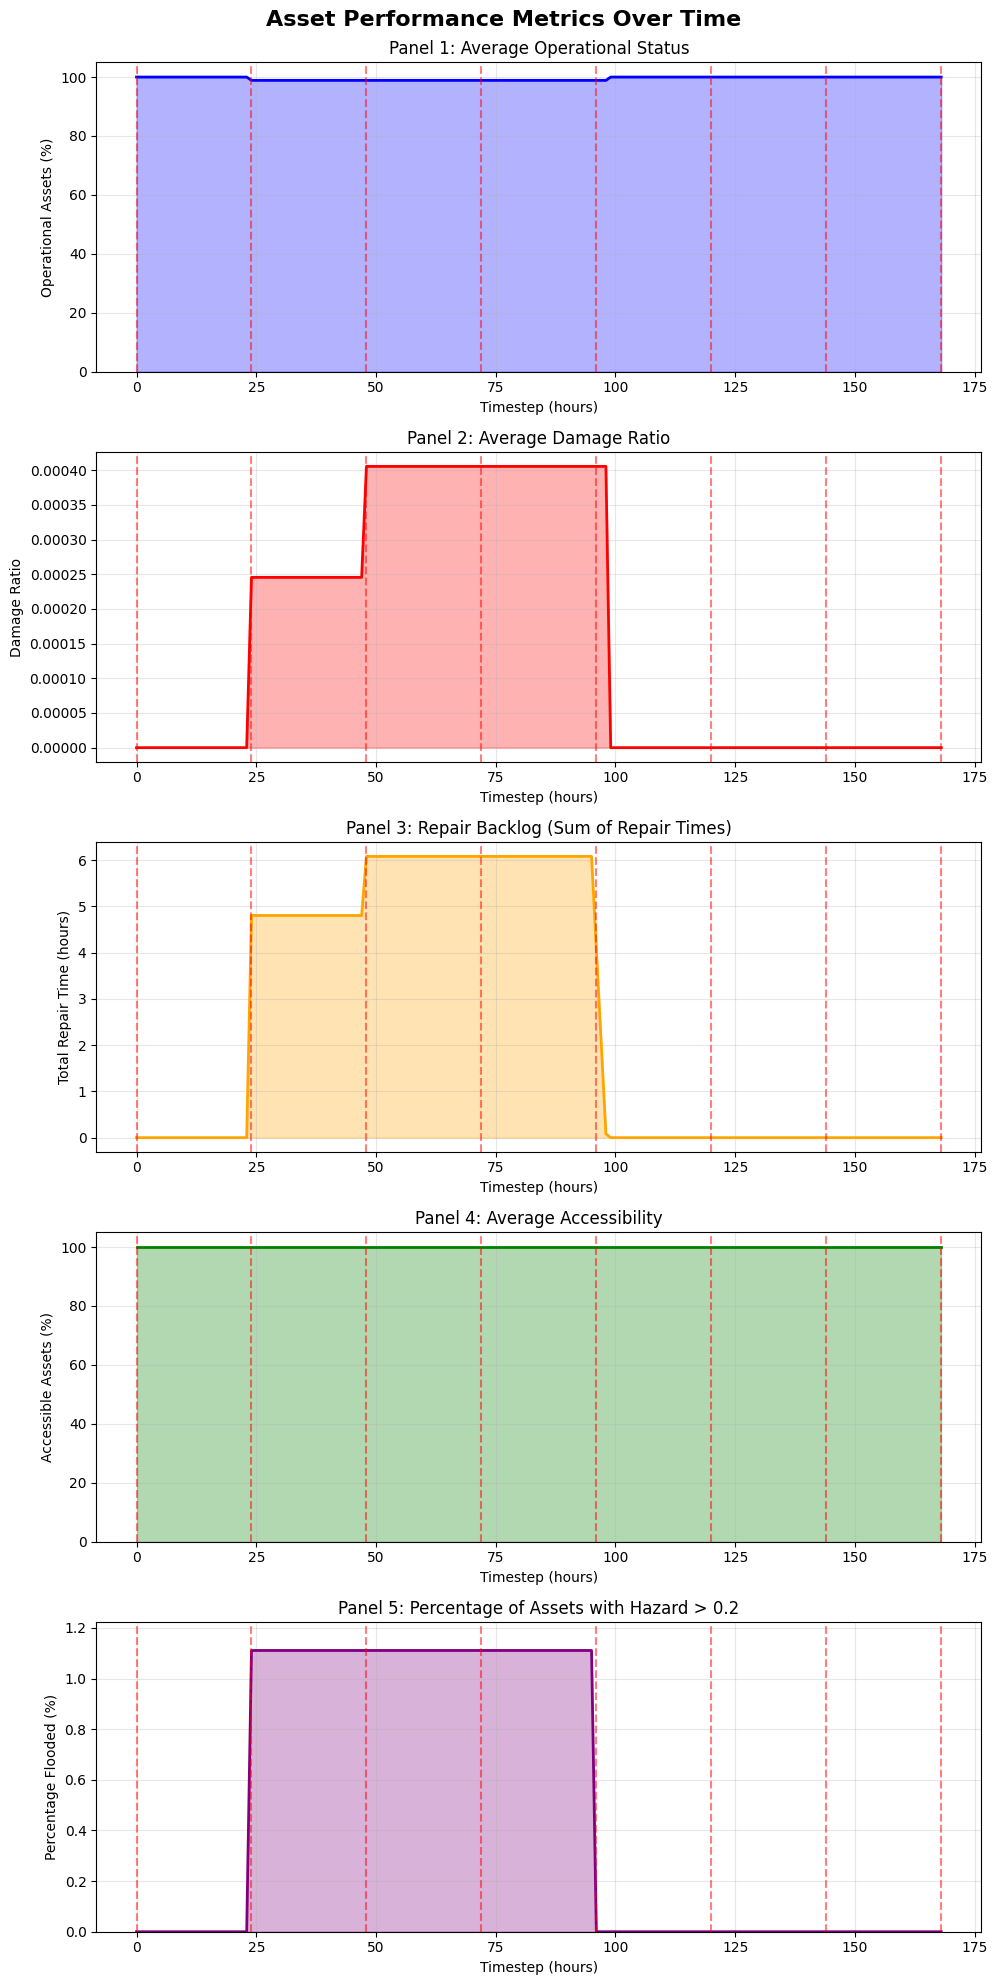

=== SUMMARY STATISTICS ===
Total timesteps analyzed: 169
Simulation duration: 168 hours (8 days)
Number of assets: 180

Final state (last timestep):
  Operational assets: 100.0%
  Average damage ratio: 0.000
  Total repair backlog: 0.0 hours
  Accessible assets: 100.0%
  Percentage flooded: 0.0%

Relevant states:
  Worst operational at timestep 24.0: 98.9%
  Maximum flooding: 1.1%
  Peak flooding occurred at timestep(s): [24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95] (absolute maximum: 1.1%)
  Top 5% flooding events (≥1.1%): 72 timesteps
  Severe flooding timesteps (showing top 10):
    Timestep 24 (Day 1, Hour 0): 1.1% flooded
    Timestep 25 (Day 1, Hour 1): 1.1% flooded
    Timestep 26 (Day 1, Hour 2): 1.1% flooded
    Timestep 27 (Day 1, Hour 3

In [18]:
# Visualisation
df_results = gpd.GeoDataFrame(results)

if 'df_results' in locals() and 'results' in locals():
    # Prepare data
    timestep_metrics = df_results.groupby('timestep').agg({
        'operational': 'mean', # Average operational status (0-1, where 1 = 100% substations are operational)
        'damage_ratio': 'mean', # Average damage ratio across all assets. [TODO] Not sure if this is very meaningful
        'repair_time': 'sum', # Total repair backlog (sum of all repair times)
        'accessible': 'mean', # Average accessibility (0-1, where 1 = 100% accessible)
        'day': 'first' # Day counter for reference, first timestep of the day, adjust based on temporal resolution
    }).reset_index()
    
    timestep_flooding = df_results.groupby('timestep').agg({
        'hazard_value': lambda x: (x > 0.2).mean() * 100,
        'day': 'first'
    }).reset_index()
    
    # Create figure with 5 subplots in single column
    fig, axes = plt.subplots(5, 1, figsize=(10, 20))
    fig.suptitle('Asset Performance Metrics Over Time', 
                 fontsize=16, fontweight='bold', y=0.99)
    # Add spacing under the suptitle to avoid overlap with panel titles
    plt.subplots_adjust(top=0.96, bottom=0.08, hspace=1.0)
    
    # Day markers
    day_markers = timestep_metrics[timestep_metrics['timestep'] % 24 == 0]['timestep']
    
    # Panel 1: Operational Status (%)
    ax1 = axes[0]
    ax1.plot(timestep_metrics['timestep'], timestep_metrics['operational'] * 100, 
             'b-', linewidth=2, label='Operational Assets')
    ax1.fill_between(timestep_metrics['timestep'], timestep_metrics['operational'] * 100, 
                     alpha=0.3, color='blue')
    ax1.set_xlabel('Timestep (hours)')
    ax1.set_ylabel('Operational Assets (%)')
    ax1.set_title('Panel 1: Average Operational Status')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 105)
    
    for day_marker in day_markers:
        ax1.axvline(x=day_marker, color='red', linestyle='--', alpha=0.5)
    
    # Panel 2: Average Damage Ratio
    ax2 = axes[1]
    ax2.plot(timestep_metrics['timestep'], timestep_metrics['damage_ratio'], 
             'r-', linewidth=2, label='Damage Ratio')
    ax2.fill_between(timestep_metrics['timestep'], timestep_metrics['damage_ratio'], 
                     alpha=0.3, color='red')
    ax2.set_xlabel('Timestep (hours)')
    ax2.set_ylabel('Damage Ratio')
    ax2.set_title('Panel 2: Average Damage Ratio')
    ax2.grid(True, alpha=0.3)
    
    for day_marker in day_markers:
        ax2.axvline(x=day_marker, color='red', linestyle='--', alpha=0.5)
    
    # Panel 3: Repair Backlog (Total Repair Time)
    ax3 = axes[2]
    ax3.plot(timestep_metrics['timestep'], timestep_metrics['repair_time'], 
             'orange', linewidth=2, label='Repair Backlog')
    ax3.fill_between(timestep_metrics['timestep'], timestep_metrics['repair_time'], 
                     alpha=0.3, color='orange')
    ax3.set_xlabel('Timestep (hours)')
    ax3.set_ylabel('Total Repair Time (hours)')
    ax3.set_title('Panel 3: Repair Backlog (Sum of Repair Times)')
    ax3.grid(True, alpha=0.3)
    
    for day_marker in day_markers:
        ax3.axvline(x=day_marker, color='red', linestyle='--', alpha=0.5)
    
    # Panel 4: Average Accessibility
    ax4 = axes[3]
    ax4.plot(timestep_metrics['timestep'], timestep_metrics['accessible'] * 100, 
             'g-', linewidth=2, label='Accessible Assets')
    ax4.fill_between(timestep_metrics['timestep'], timestep_metrics['accessible'] * 100, 
                     alpha=0.3, color='green')
    ax4.set_xlabel('Timestep (hours)')
    ax4.set_ylabel('Accessible Assets (%)')
    ax4.set_title('Panel 4: Average Accessibility')
    ax4.grid(True, alpha=0.3)
    ax4.set_ylim(0, 105)
    
    for day_marker in day_markers:
        ax4.axvline(x=day_marker, color='red', linestyle='--', alpha=0.5)
    
    # Panel 5: Percentage Flooded
    ax5 = axes[4]
    ax5.plot(timestep_flooding['timestep'], timestep_flooding['hazard_value'], 
             'purple', linewidth=2, label='Percentage Flooded')
    ax5.fill_between(timestep_flooding['timestep'], timestep_flooding['hazard_value'], 
                     alpha=0.3, color='purple')
    ax5.set_xlabel('Timestep (hours)')
    ax5.set_ylabel('Percentage Flooded (%)')
    ax5.set_title('Panel 5: Percentage of Assets with Hazard > 0.2')
    ax5.grid(True, alpha=0.3)
    ax5.set_ylim(0, max(timestep_flooding['hazard_value']) * 1.1 if max(timestep_flooding['hazard_value']) > 0 else 5)
    
    for day_marker in day_markers:
        ax5.axvline(x=day_marker, color='red', linestyle='--', alpha=0.5)
    
    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.show()
    
    # Print combined summary statistics
    print("=== SUMMARY STATISTICS ===")
    print(f"Total timesteps analyzed: {len(timestep_metrics)}")
    print(f"Simulation duration: {timestep_metrics['timestep'].max()} hours ({timestep_metrics['day'].max() + 1} days)")
    print(f"Number of assets: {len(df_results['asset_id'].unique())}")
    print()
    
    # Final state summary
    final_state = timestep_metrics.iloc[-1]
    final_flooded = timestep_flooding['hazard_value'].iloc[-1]
    print("Final state (last timestep):")
    print(f"  Operational assets: {final_state['operational']*100:.1f}%")
    print(f"  Average damage ratio: {final_state['damage_ratio']:.3f}")
    print(f"  Total repair backlog: {final_state['repair_time']:.1f} hours")
    print(f"  Accessible assets: {final_state['accessible']*100:.1f}%")
    print(f"  Percentage flooded: {final_flooded:.1f}%")
    print()
    
    # Worst state summary
    worst_operational = timestep_metrics.loc[timestep_metrics['operational'].idxmin()]
    max_flooded = timestep_flooding['hazard_value'].max()
    peak_flooding_timesteps = timestep_flooding[timestep_flooding['hazard_value'] == max_flooded]['timestep'].tolist()
    
    print("Relevant states:")
    print(f"  Worst operational at timestep {worst_operational['timestep']}: {worst_operational['operational']*100:.1f}%")
    print(f"  Maximum flooding: {max_flooded:.1f}%")
    
    # Peak flooding details - focus on top 5% of flooding events
    if max_flooded > 0:
        # Calculate the 95th percentile threshold for more selective reporting
        flood_threshold_95th = timestep_flooding['hazard_value'].quantile(0.95)
        
        # Get top 5% flooding timesteps (those >= 95th percentile)
        top_flooding_events = timestep_flooding[timestep_flooding['hazard_value'] >= flood_threshold_95th]
        top_flooding_timesteps = top_flooding_events['timestep'].tolist()
        top_flooding_values = top_flooding_events['hazard_value'].tolist()
        
        print(f"  Peak flooding occurred at timestep(s): {peak_flooding_timesteps} (absolute maximum: {max_flooded:.1f}%)")
        print(f"  Top 5% flooding events (≥{flood_threshold_95th:.1f}%): {len(top_flooding_timesteps)} timesteps")
        
        # Show details for top flooding events (limit to first 10 for readability)
        display_limit = min(10, len(top_flooding_timesteps))
        if len(top_flooding_timesteps) > 0:
            print(f"  Severe flooding timesteps (showing top {display_limit}):")
            for i in range(display_limit):
                ts = top_flooding_timesteps[i]
                flood_val = top_flooding_values[i]
                day = ts // 24
                hour = ts % 24
                print(f"    Timestep {ts} (Day {day}, Hour {hour}): {flood_val:.1f}% flooded")
            
            if len(top_flooding_timesteps) > display_limit:
                print(f"    ... and {len(top_flooding_timesteps) - display_limit} more severe flooding events")
        
        # Summary statistics for severe flooding periods
        avg_severe_flooding = top_flooding_events['hazard_value'].mean()
        print(f"  Average flooding during severe events: {avg_severe_flooding:.1f}%")
    else:
        print(f"  No flooding events detected (all hazard values ≤ 0.2)")
    
else:
    print("No simulation results available for combined visualization. Please run the simulation first.")

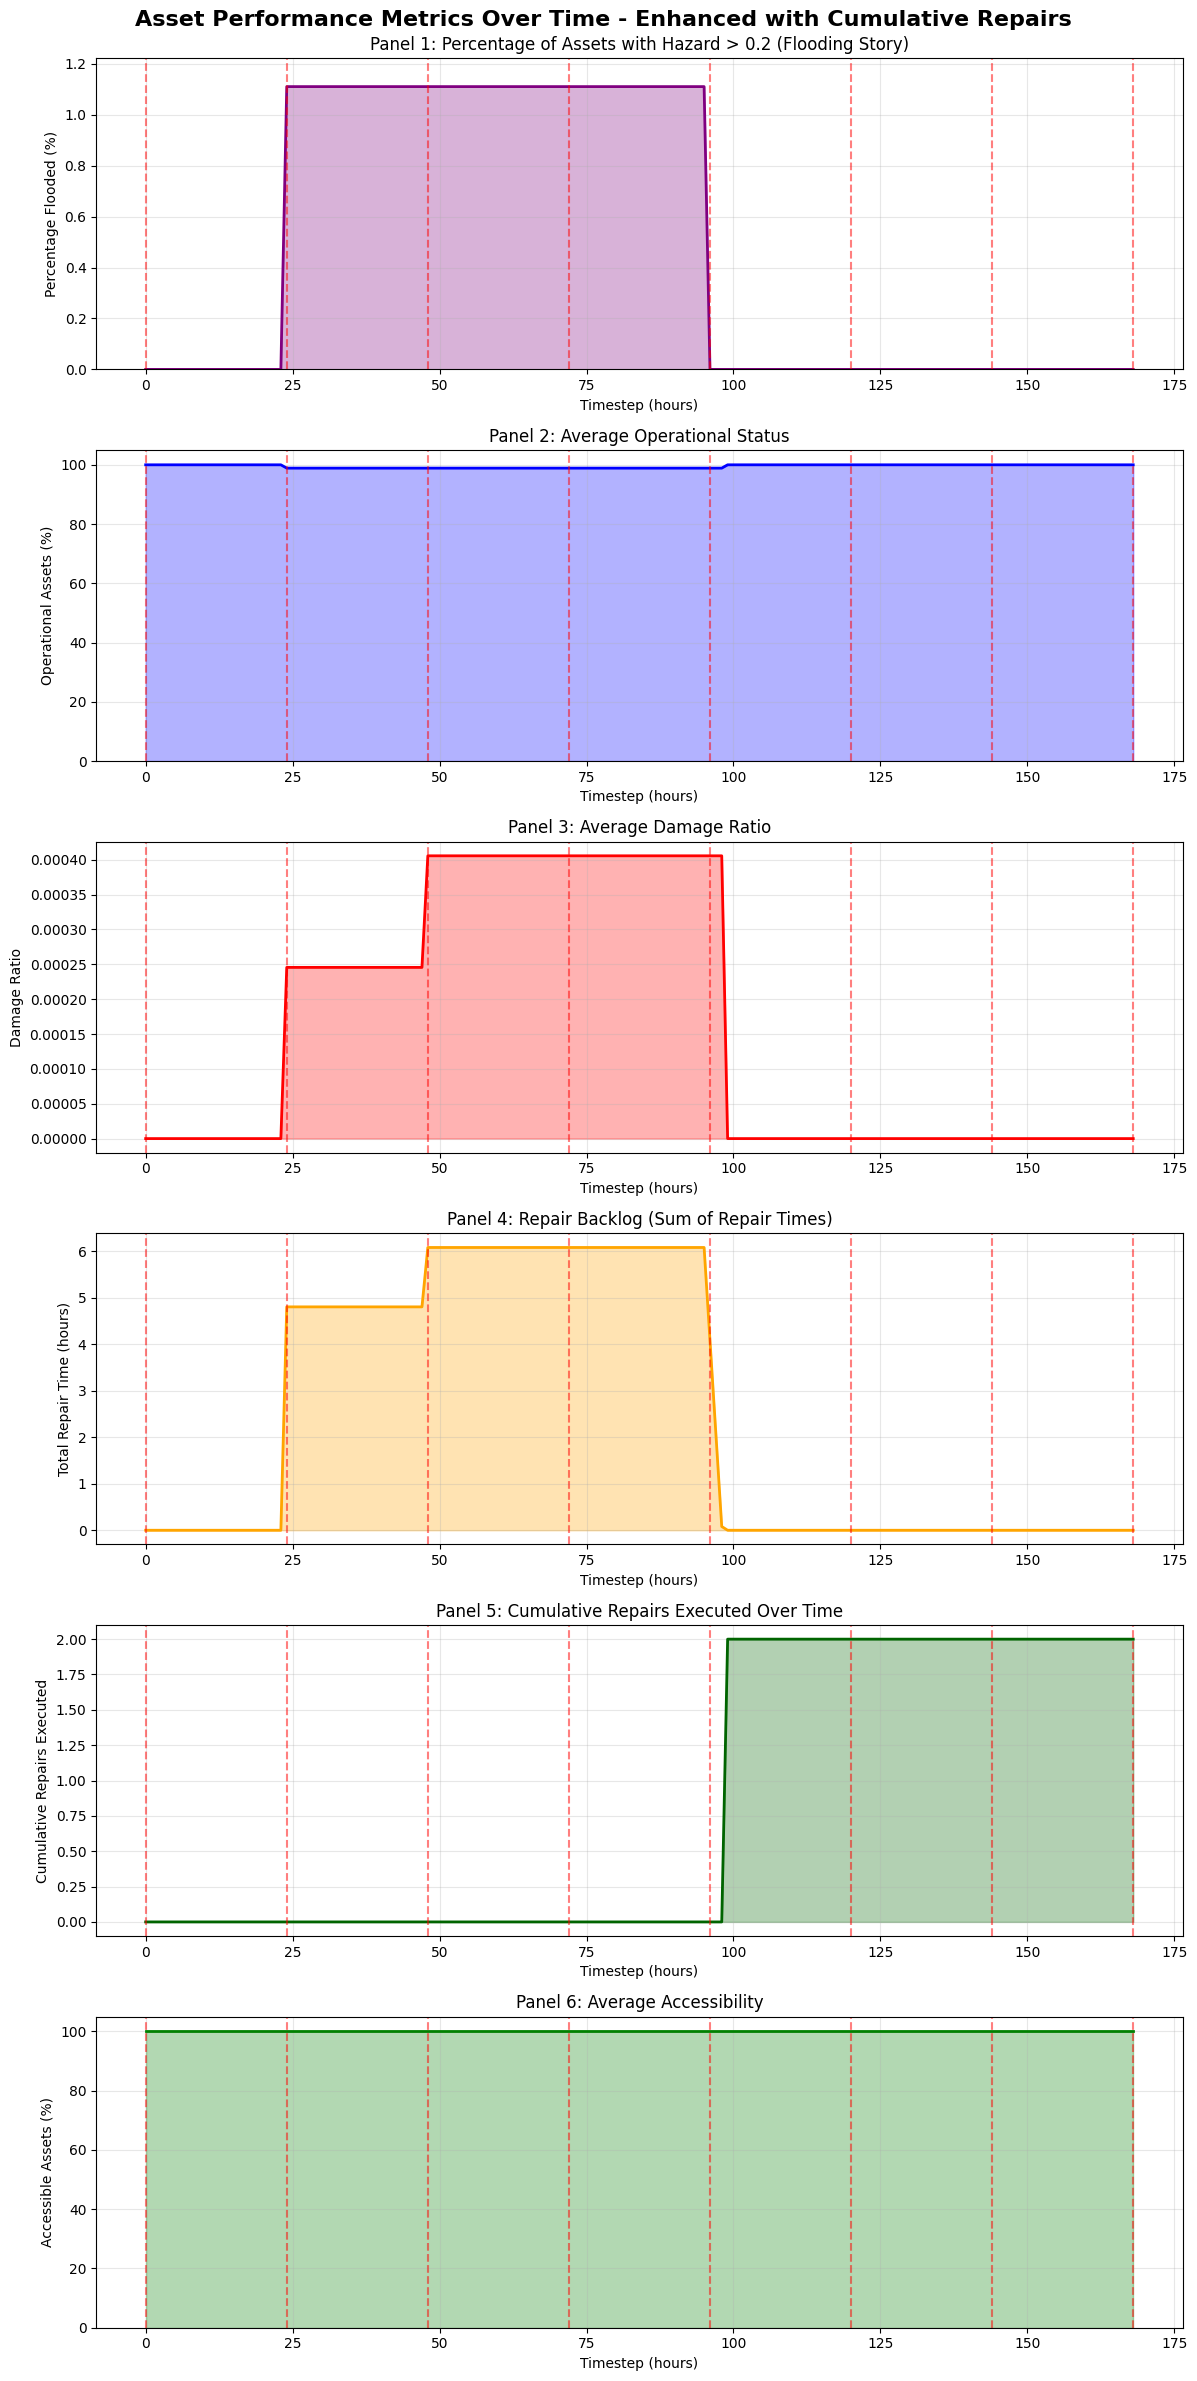

=== ENHANCED SUMMARY STATISTICS ===
Total timesteps analyzed: 169
Simulation duration: 168 hours (8 days)
Number of assets: 180
Total repairs executed: 2

Final state (last timestep):
  Operational assets: 100.0%
  Average damage ratio: 0.000
  Total repair backlog: 0.0 hours
  Accessible assets: 100.0%
  Percentage flooded: 0.0%
  Cumulative repairs executed: 2.0

Key insights:
  Worst operational at timestep 24.0: 98.9%
  Maximum flooding: 1.1%
  Repair efficiency: 2.0 repairs completed over 168 hours
  Peak flooding period: timesteps 24 to 95 (1.1% flooded)
  Flooding duration: 72 timesteps (72 hours)
  Average flooding during severe events: 1.1%


In [22]:
# Visualisation Fixed - Enhanced with Cumulative Repairs and Flooding First
df_results = gpd.GeoDataFrame(results)

if 'df_results' in locals() and 'results' in locals():
    # Prepare data
    timestep_metrics = df_results.groupby('timestep').agg({
        'operational': 'mean', # Average operational status (0-1, where 1 = 100% substations are operational)
        'damage_ratio': 'mean', # Average damage ratio across all assets. [TODO] Not sure if this is very meaningful
        'repair_time': 'sum', # Total repair backlog (sum of all repair times)
        'accessible': 'mean', # Average accessibility (0-1, where 1 = 100% accessible)
        'day': 'first' # Day counter for reference, first timestep of the day, adjust based on temporal resolution
    }).reset_index()
    
    timestep_flooding = df_results.groupby('timestep').agg({
        'hazard_value': lambda x: (x > 0.2).mean() * 100,
        'day': 'first'
    }).reset_index()
    
    # Calculate cumulative repairs executed
    # Track when assets complete repairs (repair_time goes from >0 to 0)
    cumulative_repairs = []
    repairs_executed = 0
    
    for timestep in sorted(df_results['timestep'].unique()):
        current_data = df_results[df_results['timestep'] == timestep]
        prev_timestep = timestep - 1
        
        if prev_timestep >= 0:
            prev_data = df_results[df_results['timestep'] == prev_timestep]
            if not prev_data.empty:
                # Count assets that had repair_time > 0 in previous timestep and = 0 in current timestep
                for asset_id in current_data['asset_id'].unique():
                    current_repair = current_data[current_data['asset_id'] == asset_id]['repair_time'].iloc[0]
                    prev_repair_match = prev_data[prev_data['asset_id'] == asset_id]
                    if not prev_repair_match.empty:
                        prev_repair = prev_repair_match['repair_time'].iloc[0]
                        if prev_repair > 0 and current_repair == 0:
                            repairs_executed += 1
        
        cumulative_repairs.append(repairs_executed)
    
    timestep_metrics['cumulative_repairs'] = cumulative_repairs
    
    # Create figure with 6 subplots in single column
    fig, axes = plt.subplots(6, 1, figsize=(12, 24))
    fig.suptitle('Asset Performance Metrics Over Time - Enhanced with Cumulative Repairs', 
                 fontsize=16, fontweight='bold', y=0.99)
    # Add spacing under the suptitle to avoid overlap with panel titles
    plt.subplots_adjust(top=0.96, bottom=0.04, hspace=0.8)
    
    # Day markers
    day_markers = timestep_metrics[timestep_metrics['timestep'] % 24 == 0]['timestep']
    
    # Panel 1: Percentage Flooded (moved to first to tell the story)
    ax1 = axes[0]
    ax1.plot(timestep_flooding['timestep'], timestep_flooding['hazard_value'], 
             'purple', linewidth=2, label='Percentage Flooded')
    ax1.fill_between(timestep_flooding['timestep'], timestep_flooding['hazard_value'], 
                     alpha=0.3, color='purple')
    ax1.set_xlabel('Timestep (hours)')
    ax1.set_ylabel('Percentage Flooded (%)')
    ax1.set_title('Panel 1: Percentage of Assets with Hazard > 0.2 (Flooding Story)')
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, max(timestep_flooding['hazard_value']) * 1.1 if max(timestep_flooding['hazard_value']) > 0 else 5)
    
    for day_marker in day_markers:
        ax1.axvline(x=day_marker, color='red', linestyle='--', alpha=0.5)
    
    # Panel 2: Operational Status (%)
    ax2 = axes[1]
    ax2.plot(timestep_metrics['timestep'], timestep_metrics['operational'] * 100, 
             'b-', linewidth=2, label='Operational Assets')
    ax2.fill_between(timestep_metrics['timestep'], timestep_metrics['operational'] * 100, 
                     alpha=0.3, color='blue')
    ax2.set_xlabel('Timestep (hours)')
    ax2.set_ylabel('Operational Assets (%)')
    ax2.set_title('Panel 2: Average Operational Status')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(0, 105)
    
    for day_marker in day_markers:
        ax2.axvline(x=day_marker, color='red', linestyle='--', alpha=0.5)
    
    # Panel 3: Average Damage Ratio
    ax3 = axes[2]
    ax3.plot(timestep_metrics['timestep'], timestep_metrics['damage_ratio'], 
             'r-', linewidth=2, label='Damage Ratio')
    ax3.fill_between(timestep_metrics['timestep'], timestep_metrics['damage_ratio'], 
                     alpha=0.3, color='red')
    ax3.set_xlabel('Timestep (hours)')
    ax3.set_ylabel('Damage Ratio')
    ax3.set_title('Panel 3: Average Damage Ratio')
    ax3.grid(True, alpha=0.3)
    
    for day_marker in day_markers:
        ax3.axvline(x=day_marker, color='red', linestyle='--', alpha=0.5)
    
    # Panel 4: Repair Backlog (Total Repair Time)
    ax4 = axes[3]
    ax4.plot(timestep_metrics['timestep'], timestep_metrics['repair_time'], 
             'orange', linewidth=2, label='Repair Backlog')
    ax4.fill_between(timestep_metrics['timestep'], timestep_metrics['repair_time'], 
                     alpha=0.3, color='orange')
    ax4.set_xlabel('Timestep (hours)')
    ax4.set_ylabel('Total Repair Time (hours)')
    ax4.set_title('Panel 4: Repair Backlog (Sum of Repair Times)')
    ax4.grid(True, alpha=0.3)
    
    for day_marker in day_markers:
        ax4.axvline(x=day_marker, color='red', linestyle='--', alpha=0.5)
    
    # Panel 5: Cumulative Repairs Executed (NEW)
    ax5 = axes[4]
    ax5.plot(timestep_metrics['timestep'], timestep_metrics['cumulative_repairs'], 
             'darkgreen', linewidth=2, label='Cumulative Repairs')
    ax5.fill_between(timestep_metrics['timestep'], timestep_metrics['cumulative_repairs'], 
                     alpha=0.3, color='darkgreen')
    ax5.set_xlabel('Timestep (hours)')
    ax5.set_ylabel('Cumulative Repairs Executed')
    ax5.set_title('Panel 5: Cumulative Repairs Executed Over Time')
    ax5.grid(True, alpha=0.3)
    
    for day_marker in day_markers:
        ax5.axvline(x=day_marker, color='red', linestyle='--', alpha=0.5)
    
    # Panel 6: Average Accessibility
    ax6 = axes[5]
    ax6.plot(timestep_metrics['timestep'], timestep_metrics['accessible'] * 100, 
             'g-', linewidth=2, label='Accessible Assets')
    ax6.fill_between(timestep_metrics['timestep'], timestep_metrics['accessible'] * 100, 
                     alpha=0.3, color='green')
    ax6.set_xlabel('Timestep (hours)')
    ax6.set_ylabel('Accessible Assets (%)')
    ax6.set_title('Panel 6: Average Accessibility')
    ax6.grid(True, alpha=0.3)
    ax6.set_ylim(0, 105)
    
    for day_marker in day_markers:
        ax6.axvline(x=day_marker, color='red', linestyle='--', alpha=0.5)
    
    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.show()
    
    # Print enhanced summary statistics
    print("=== ENHANCED SUMMARY STATISTICS ===")
    print(f"Total timesteps analyzed: {len(timestep_metrics)}")
    print(f"Simulation duration: {timestep_metrics['timestep'].max()} hours ({timestep_metrics['day'].max() + 1} days)")
    print(f"Number of assets: {len(df_results['asset_id'].unique())}")
    print(f"Total repairs executed: {timestep_metrics['cumulative_repairs'].iloc[-1]}")
    print()
    
    # Final state summary
    final_state = timestep_metrics.iloc[-1]
    final_flooded = timestep_flooding['hazard_value'].iloc[-1]
    print("Final state (last timestep):")
    print(f"  Operational assets: {final_state['operational']*100:.1f}%")
    print(f"  Average damage ratio: {final_state['damage_ratio']:.3f}")
    print(f"  Total repair backlog: {final_state['repair_time']:.1f} hours")
    print(f"  Accessible assets: {final_state['accessible']*100:.1f}%")
    print(f"  Percentage flooded: {final_flooded:.1f}%")
    print(f"  Cumulative repairs executed: {final_state['cumulative_repairs']}")
    print()
    
    # Worst state summary
    worst_operational = timestep_metrics.loc[timestep_metrics['operational'].idxmin()]
    max_flooded = timestep_flooding['hazard_value'].max()
    peak_flooding_timesteps = timestep_flooding[timestep_flooding['hazard_value'] == max_flooded]['timestep'].tolist()
    
    print("Key insights:")
    print(f"  Worst operational at timestep {worst_operational['timestep']}: {worst_operational['operational']*100:.1f}%")
    print(f"  Maximum flooding: {max_flooded:.1f}%")
    print(f"  Repair efficiency: {final_state['cumulative_repairs']} repairs completed over {timestep_metrics['timestep'].max()} hours")
    
    # Peak flooding details - focus on top 5% of flooding events
    if max_flooded > 0:
        # Calculate the 95th percentile threshold for more selective reporting
        flood_threshold_95th = timestep_flooding['hazard_value'].quantile(0.95)
        
        # Get top 5% flooding timesteps (those >= 95th percentile)
        top_flooding_events = timestep_flooding[timestep_flooding['hazard_value'] >= flood_threshold_95th]
        top_flooding_timesteps = top_flooding_events['timestep'].tolist()
        top_flooding_values = top_flooding_events['hazard_value'].tolist()
        
        print(f"  Peak flooding period: timesteps {min(peak_flooding_timesteps)} to {max(peak_flooding_timesteps)} ({max_flooded:.1f}% flooded)")
        print(f"  Flooding duration: {len(peak_flooding_timesteps)} timesteps ({len(peak_flooding_timesteps)} hours)")
        
        # Summary statistics for severe flooding periods
        avg_severe_flooding = top_flooding_events['hazard_value'].mean()
        print(f"  Average flooding during severe events: {avg_severe_flooding:.1f}%")
    else:
        print(f"  No flooding events detected (all hazard values ≤ 0.2)")
    
else:
    print("No simulation results available for enhanced visualization. Please run the simulation first.")

Additional to repair backlog, include cumulative repairs executed, and make flooded assets first panel to tell the story


In [ ]:
# import folium
# from folium.plugins import TimestampedGeoJson

# # Add geometry to df_results from gdf_msls_2
# if 'geometry' not in df_results.columns:
#     df_results['geometry'] = gdf_msls_2['geometry'].repeat(len(df_results) // len(gdf_msls_2)).reset_index(drop=True)

# # Prepare GeoJSON features for each timestep
# features = []
# for ts in sorted(df_results['timestep'].unique()):
#     timestep_data = df_results[df_results['timestep'] == ts]
#     for _, row in timestep_data.iterrows():
#         color = 'green' if row['operational'] else 'red'
#         feature = {
#             'type': 'Feature',
#             'geometry': row['geometry'].__geo_interface__,
#             'properties': {
#                 'time': f"2022-06-{(row['day']+3):02d}T{ts%24:02d}:00:00",
#                 'style': {'color': color, 'fillColor': color, 'radius': 5},
#                 'icon': 'circle',
#                 'popup': f"Asset {row['asset_id']}<br>Status: {'Operational' if row['operational'] else 'Non-operational'}"
#             }
#         }
#         features.append(feature)

# # Create the TimestampedGeoJson map
# m_dynamic = folium.Map(location=[52.0, 4.4], zoom_start=10)
# TimestampedGeoJson(
#     {'type': 'FeatureCollection', 'features': features},
#     period='PT1H',
#     add_last_point=True,
#     auto_play=False,
#     loop=False,
#     max_speed=1,
#     loop_button=True,
#     date_options='YYYY-MM-DD HH:mm',
#     time_slider_drag_update=True
# ).add_to(m_dynamic)

# m_dynamic

C:\Users\peregrin\AppData\Local\Temp\ipykernel_12640\1094676864.py:6: FutureWarning: You are adding a column named 'geometry' to a GeoDataFrame constructed without an active geometry column. Currently, this automatically sets the active geometry column to 'geometry' but in the future that will no longer happen. Instead, either provide geometry to the GeoDataFrame constructor (GeoDataFrame(... geometry=GeoSeries()) or use `set_geometry('geometry')` to explicitly set the active geometry column.
  df_results['geometry'] = gdf_msls_2['geometry'].repeat(len(df_results) // len(gdf_msls_2)).reset_index(drop=True)


# Recovery with accessibility

In [26]:
import importlib
import sys
from pathlib import Path

# Ensure src is in sys.path for module import
src_path = root_dir / "src"
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

def simulate_asset_damage_recovery_access(
    gdf_assets, 
    hazard_path, 
    timesteps=None,
    damage_ratio_func=default_damage_ratio_function,
    repair_time_func=default_repair_time_function,
    damage_ratio_coefficients=(0.0468, 0.0077), #(FEMA, 2009; Sánchez-Muñoz et al., 2020) USA
    repair_time_coefficients=(702.72, 3.14, 1.9891), #(Sánchez-Muñoz et al., 2020) Bristol(UK)/Barcelona(SP)
    flood_threshold=0.2, # Ref?
    repair_threshold=2.0, # Repair time threshold for recovery calculation, set to 2 hours (1.9891) as lower limit of the repair time curve
    record_results=True,
    verbose=True,
    accessibility_model= None # Optional model for asset accessibility
):
    """
    Simulate asset damage and recovery over timesteps using NumPy arrays for optimization.
    
    Parameters:
    gdf_assets (gpd.GeoDataFrame): GeoDataFrame with asset geometries
    hazard_path (Path): Path to hazard map files
    timesteps (np.array): Array of timestep values (default: 0 to 7*24+1)
    damage_ratio_func (callable): Function to calculate damage ratio from hazard values
    repair_time_func (callable): Function to calculate repair time from damage ratios
    damage_ratio_coefficients (tuple): Coefficients for damage ratio function (m, n)
    repair_time_coefficients (tuple): Coefficients for repair time polynomial (a, b, c)
    flood_threshold (float): Hazard value threshold for flooding (default: 0.2)
    repair_threshold (float): Repair time threshold for recovery calculation (default: 2.0)
    record_results (bool): Whether to record timestep results (default: True)
    verbose (bool): Whether to print progress messages (default: True)
    
    Returns:
    tuple: (final_gdf, results_dict) - Final asset states and recorded results
    """
    if accessibility_model is not None:
        if callable(accessibility_model):
            # If a callable model is provided, use it directly
            accessibility_model = accessibility_model
        else:
            # Otherwise, assume it's a string path to a model function
            try:
                import importlib.util
                import sys
                from pathlib import Path

                # Support for "src.accessibility_analysis"
                if accessibility_model == "src.accessibility_analysis":
                    src_path = root_dir / "src" / "accessibility_analysis.py"
                    spec = importlib.util.spec_from_file_location("accessibility_analysis", src_path)
                    module = importlib.util.module_from_spec(spec)
                    sys.modules["accessibility_analysis"] = module
                    spec.loader.exec_module(module)
                    accessibility_model = module.accessibility_model if hasattr(module, "accessibility_model") else module
                    print(f"Accessibility model loaded from {src_path}")
                else:
                    accessibility_model = importlib.import_module(accessibility_model)
                    print(f"Accessibility model imported from {accessibility_model}")
            except Exception as e:
                raise ValueError(f"Could not import accessibility model: {e}")

    if timesteps is None:
        timesteps = np.arange(0, 7*24+1, 1)

    # Convert to NumPy arrays for optimized operations
    n_assets = len(gdf_assets)

    # Initialize NumPy arrays for asset states
    damage_ratio = np.zeros(n_assets, dtype=np.float64)
    repair_time = np.zeros(n_assets, dtype=np.float64)
    accessible = np.ones(n_assets, dtype=bool)
    operational = np.ones(n_assets, dtype=bool)
    current_hazard_values = np.zeros(n_assets, dtype=np.float64)

    # Create temporary GeoDataFrame for hazard value extraction
    temp_gdf = gdf_assets.copy()

    # Results recording
    recorded_variables = ['asset_id', 'timestep', 'day', 'damage_ratio', 'repair_time', 'accessible', 'operational', 'hazard_value']
    results = {var: [] for var in recorded_variables} if record_results else None

    # Iterate over each timestep
    for timestep in timesteps:
        day_counter = timestep // 24
        day_counter_str = str(day_counter).zfill(2)

        # Every 24 hour-timesteps, process the hazard map for that day
        if timestep % 24 == 0:
            # Load hazard map for this day
            hazard_map = hazard_path / f'clipped_hazard_map_{day_counter:02d}.tif'
            if not hazard_map.exists():
                if verbose:
                    print(f"Warning: Hazard map for day {day_counter} does not exist at {hazard_map}")
                current_hazard_values.fill(0.0)
            else:
                if verbose:
                    print(f"Processing timestep {timestep} (day {day_counter})")
                # Extract hazard values using the existing function
                temp_gdf = find_hazard_value_at_points(hazard_map, temp_gdf, day_counter)
                haz_val_str = f'hazard_value_{day_counter_str}'
                current_hazard_values = temp_gdf[haz_val_str].fillna(0.0).values

            # Vectorized operations using NumPy arrays
            flooded_mask = current_hazard_values > flood_threshold
            operational[flooded_mask] = False

            # For assets under repair, solve for current damage ratio
            repair_mask = repair_time > repair_threshold
            if np.any(repair_mask):
                repair_indices = np.where(repair_mask)[0]
                for idx in repair_indices:
                    damage_ratio[idx] = solve_damage_ratio_from_repair_time(
                        repair_time[idx], repair_time_coefficients
                    )

            # Update damage ratio for flooded assets (cumulative damage)
            if np.any(flooded_mask):
                dr_new = damage_ratio_func(current_hazard_values[flooded_mask], damage_ratio_coefficients)
                damage_ratio[flooded_mask] = np.maximum(damage_ratio[flooded_mask], dr_new)

            # Only recalculate repair time for assets with damage > 0
            damaged_mask = damage_ratio > 0
            if np.any(damaged_mask):
                repair_time[damaged_mask] = repair_time_func(
                    damage_ratio[damaged_mask], repair_time_coefficients
                )

            # If an accessibility model is provided, update accessibility WATCHOUT: calculated on day-basis, not hourly
            # If accessibility model works with repair timesteps, this should be moved out of day loop
            if accessibility_model is not None:
                accessible = accessibility_model(gdf_assets.geometry, hazard_map, current_hazard_values)
                if verbose:
                    print(f"Accessibility updated for timestep {timestep} (day {day_counter})")
                    print(f"Accessible assets: {accessible.sum()} out of {n_assets}")

        # For each timestep, decrement repair_time if accessible and not flooded [TODO]: add if available repair crews/resources 
        can_repair_mask = accessible & (current_hazard_values <= 0.0)
        repair_time[can_repair_mask] = np.maximum(repair_time[can_repair_mask] - 1, 0)
        
        # Check for completed repairs
        newly_operational = (repair_time == 0) & (~operational)
        if np.any(newly_operational):
            operational[newly_operational] = True
            damage_ratio[newly_operational] = 0.0
            if verbose:
                newly_operational_indices = np.where(newly_operational)[0]
                for idx in newly_operational_indices:
                    print(f"Asset {idx} is operational at timestep {timestep}")

        # Record results for each asset at this timestep
        if record_results:
            n_records = len(damage_ratio)
            results['asset_id'].extend(range(n_records))
            results['timestep'].extend([timestep] * n_records)
            results['day'].extend([day_counter] * n_records)
            results['damage_ratio'].extend(damage_ratio.tolist())
            results['repair_time'].extend(repair_time.tolist())
            results['accessible'].extend(accessible.tolist())
            results['operational'].extend(operational.tolist())
            results['hazard_value'].extend(current_hazard_values.tolist())

    if verbose:
        print("Processing complete")

    # Convert final results back to GeoDataFrame for compatibility
    final_gdf = gdf_assets.copy()
    final_gdf['damage_ratio'] = damage_ratio
    final_gdf['repair_time'] = repair_time
    final_gdf['accessible'] = accessible
    final_gdf['operational'] = operational
    final_gdf['final_hazard_value'] = current_hazard_values

    return final_gdf, results

# Run simulation with the default parameters for repair time and damage ratio functions
gdf_msls_timesteps, results = simulate_asset_damage_recovery_access(
    gdf_msls_2, # GeoDataFrame with station geometries
    hazard_path, # Path to hazard maps
    timesteps=np.arange(0, 7*24+1, 1), # 24-hour timesteps for 7 days
    verbose=True, # Print progress messages
    record_results=True, # Record results for each timestep
    flood_threshold=0.2, # [m] threshold for flooding
    repair_threshold=2.0, # [hours] threshold for repair time to be considered under repair
    accessibility_model= "src.accessibility_analysis"
)

gdf_msls_timesteps.head()

Accessibility model loaded from c:\repos\powerpath\src\accessibility_analysis.py
Processing timestep 0 (day 0)
Creating baseline analysis (this may take a while)...
Creating baseline grid analysis...


Calculating baseline distances: 100%|██████████| 238/238 [00:41<00:00,  5.72it/s]


Baseline analysis complete! Created grid with 238 cells.
Running hazard analysis for c:\repos\powerpath\data\static\hazard\processed\timesteps\clipped_hazard_map_00.tif...
Step 1: Running RA2CE hazard analysis...
RA2CE analysis completed for clipped_hazard_map_00.tif
Step 2: Loading hazard-analyzed roads...
Step 3: Calculating road length impacts...
Analysis complete! Processed 238 grid cells.
Accessibility updated for timestep 0 (day 0)
Accessible assets: 180 out of 180
Processing timestep 24 (day 1)
Running hazard analysis for c:\repos\powerpath\data\static\hazard\processed\timesteps\clipped_hazard_map_01.tif...
Step 1: Running RA2CE hazard analysis...
RA2CE analysis completed for clipped_hazard_map_01.tif
Step 2: Loading hazard-analyzed roads...
Step 3: Calculating road length impacts...
Analysis complete! Processed 238 grid cells.
Accessibility updated for timestep 24 (day 1)
Accessible assets: 178 out of 180
Processing timestep 48 (day 2)
Running hazard analysis for c:\repos\power

,geometry,damage_ratio,repair_time,accessible,operational,final_hazard_value
0,POINT (79889.975 454542.815),0.0,0.0,True,True,0.0
1,POINT (80672.808 454552.688),0.0,0.0,True,True,0.0
2,POINT (79827.733 454571.309),0.0,0.0,True,True,0.0
3,POINT (80065.110 454570.833),0.0,0.0,True,True,0.0
4,POINT (80165.189 454574.888),0.0,0.0,True,True,0.0


# Hoogspanning heeft geen exposure

# Laagspanning

In [27]:
gdf_ls_2 = gpd.GeoDataFrame()
gdf_ls_2['geometry'] = gdf_ls.geometry
# gdf_ls_2

In [28]:
# Read the raster file
with rasterio.open(hazard_map) as src:
    # Read the TIF file as a numpy array
    tif_array = src.read(1)  # Change the band index (1) if necessary

    # Get the CRS from the rasterio object
    raster_crs = src.crs

    points = gdf_ls_2

    # Ensure CRS match
    points = points.to_crs(raster_crs)
    points2 = gpd.clip(points, buffer_polygon_network)

    # Filter points that fall within the raster bounds
    points2 = points2[points2.geometry.apply(lambda point: 0 <= src.index(point.x, point.y)[0] < src.height and 0 <= src.index(point.x, point.y)[1] < src.width)]

    # Add a new column to store hazard values
    points2['hazard_value'] = points2.geometry.apply(lambda point: get_raster_value(src, point))



In [29]:
points_with_hazard = points2[points2['hazard_value'] > 0.2]
if points_with_hazard.empty:
    print("No points with hazard values greater than 0.2 found.")
else:
    points_with_hazard.explore(column='hazard_value', cmap='viridis_r', tiles='CartoDB positron',marker_kwds={'radius': 6})

No points with hazard values greater than 0.2 found.


In [30]:
result = assign_hazard_to_voronoi(points_with_hazard, voronoi_gdf_ls)
result_with_hazard = result[result['hazard_value']>0.2]
if result_with_hazard.empty:
    print("No Voronoi polygons with hazard values greater than 0.2 found.")
else:
    result_with_hazard.explore(column='hazard_value',cmap='viridis_r', tiles='CartoDB positron')


No Voronoi polygons with hazard values greater than 0.2 found.
